# Posterior for local recombination and mutation rate using SBI + SBC

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NRE_B
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load genome data and clonal tree.

In [2]:
clonal_edge = np.loadtxt("../data/ClonalOrigin/clonal_edge.csv", delimiter=",", dtype=float)
clonal_node_height = np.loadtxt("../data/ClonalOrigin/clonal_node_height.csv", delimiter=",", dtype=float)

In [3]:
clonal_edge, clonal_node_height

(array([[3.10000000e+01, 1.40000000e+01, 1.80220314e-03],
        [3.10000000e+01, 2.90000000e+01, 1.80220314e-03],
        [3.20000000e+01, 2.80000000e+01, 5.97471972e-03],
        [3.20000000e+01, 2.60000000e+01, 5.97471972e-03],
        [3.30000000e+01, 3.00000000e+00, 8.25024952e-03],
        [3.30000000e+01, 2.70000000e+01, 8.25024952e-03],
        [3.40000000e+01, 2.20000000e+01, 1.30036692e-02],
        [3.40000000e+01, 1.00000000e+01, 1.30036692e-02],
        [3.50000000e+01, 1.10000000e+01, 2.34636374e-02],
        [3.50000000e+01, 1.80000000e+01, 2.34636374e-02],
        [3.60000000e+01, 3.30000000e+01, 1.80941931e-02],
        [3.60000000e+01, 2.10000000e+01, 2.63444427e-02],
        [3.70000000e+01, 1.70000000e+01, 3.56575696e-02],
        [3.70000000e+01, 6.00000000e+00, 3.56575696e-02],
        [3.80000000e+01, 1.20000000e+01, 3.73864931e-02],
        [3.80000000e+01, 3.20000000e+01, 3.14117734e-02],
        [3.90000000e+01, 3.00000000e+01, 3.85383268e-02],
        [3.900

## Summary statistics

In [4]:
x_500 = np.loadtxt("../data/ClonalOrigin/x_o_500.csv", delimiter=",")
x_2000 = np.loadtxt("../data/ClonalOrigin/x_o_2000.csv", delimiter=",")
x_6000 = np.loadtxt("../data/ClonalOrigin/x_o_6000.csv", delimiter=",")

x_500.shape, x_2000.shape, x_6000.shape

((100, 46), (100, 46), (100, 46))

In [5]:
theta1 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/x3.csv', delimiter=",")

theta4 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/ClonalOrigin/rho_and_theta/x4.csv', delimiter=",")

x = np.vstack([x1, x2, x3, x4])
theta = np.vstack([theta1, theta2, theta3, theta4])

print(theta.shape, x.shape)

(50000, 3) (50000, 46)


In [6]:
drop_indices = np.unique(np.concatenate([np.where(np.isnan(x))[0], np.where(np.isinf(x))[0]]))
drop_indices

array([  114,   681,   706,  1448,  2554,  2818,  7211,  7282,  7329,
        7392,  8938,  9827,  9973, 10223, 10788, 12192, 13567, 14388,
       14653, 20248, 21831, 22683, 23165, 24293, 24995, 26727, 27136,
       28568, 29040, 29263, 30213, 31152, 31611, 32633, 33029, 33132,
       34118, 34453, 34659, 35788, 35955, 40017, 40926, 41346, 42815,
       43524, 43687, 47022, 49215, 49429, 49517, 49777])

In [7]:
theta = np.delete(theta, drop_indices, axis=0)
x = np.delete(x, drop_indices, axis=0)

theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

## NPE

### Create prior to pass range knowledge to NPE

In [8]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [9]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference1 = NRE_B(prior=prior, classifier="resnet", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [10]:
density_estimator1 = inference1.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior1 = inference1.build_posterior(density_estimator1)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\base.py:296: UserWarning: Data has extreme outliers in dimension(s) [6, 7, 8, 9, 12, 13, 24, 25, 26, 27, 28, 29, 30, 36, 38, 39, 41, 42, 43, 44] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 85 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NRE_B\2026-07-06T16_23_39.740838' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


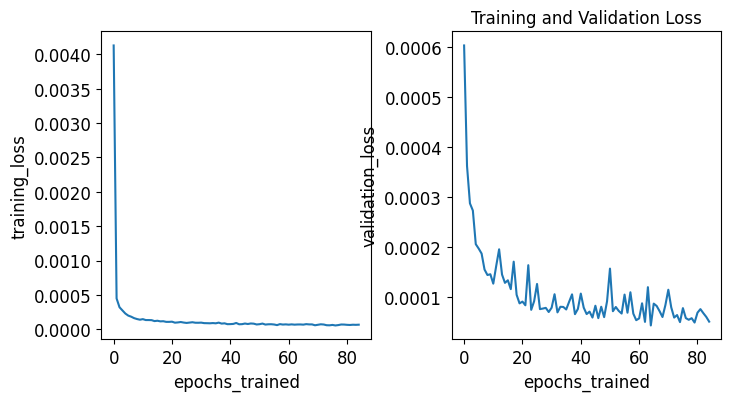

In [11]:
fig, axes = plot_summary(
    inference1, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### ClonalOrigin observations

In [12]:
theta1_500 = np.full((100, num_posterior_samples, 3), np.nan)
theta1_2000 = np.full((100, num_posterior_samples, 3), np.nan)
theta1_6000 = np.full((100, num_posterior_samples, 3), np.nan)

theta1_500.shape, theta1_2000.shape, theta1_6000.shape

((100, 1000, 3), (100, 1000, 3), (100, 1000, 3))

In [ ]:
for i in range(100):
    x_obs = torch.tensor(x_500[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs, show_progress_bars=False)
    theta1_500[i, :, :] = theta_post.cpu().numpy()

Running vectorized MCMC with 20 chains:  60%|██████    | 3600/6000 [00:02<00:01, 1770.34it/s]

KeyboardInterrupt: 

In [14]:
for i in range(100):
    x_obs = torch.tensor(x_2000[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs, show_progress_bars=False)
    theta1_2000[i, :, :] = theta_post.cpu().numpy()

In [15]:
for i in range(100):
    x_obs = torch.tensor(x_6000[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs, show_progress_bars=False)
    theta1_6000[i, :, :] = theta_post.cpu().numpy()

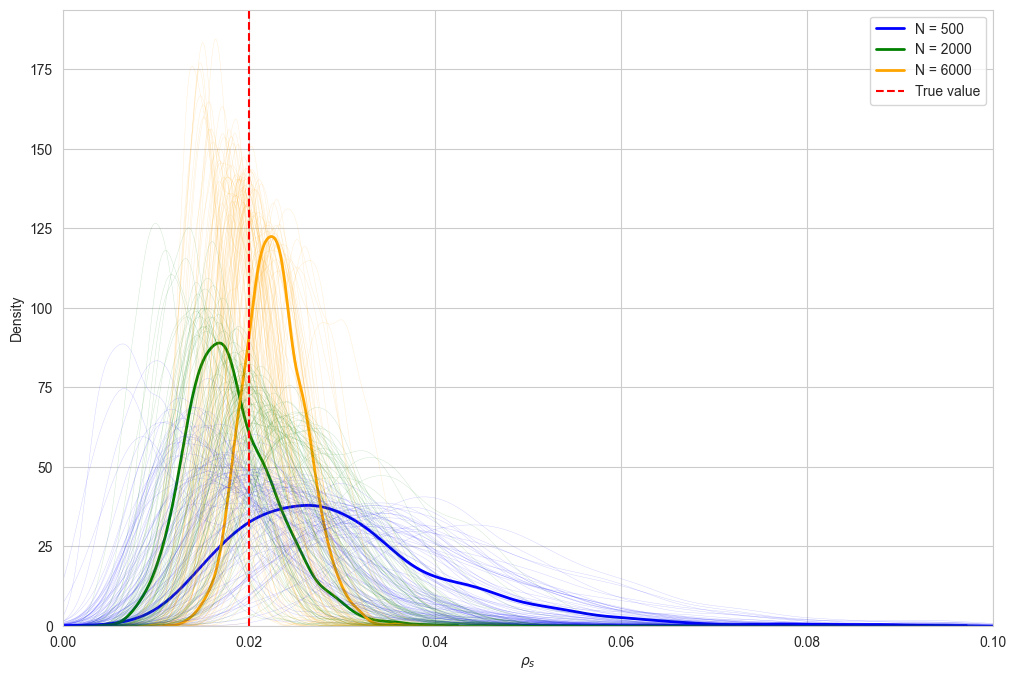

In [16]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

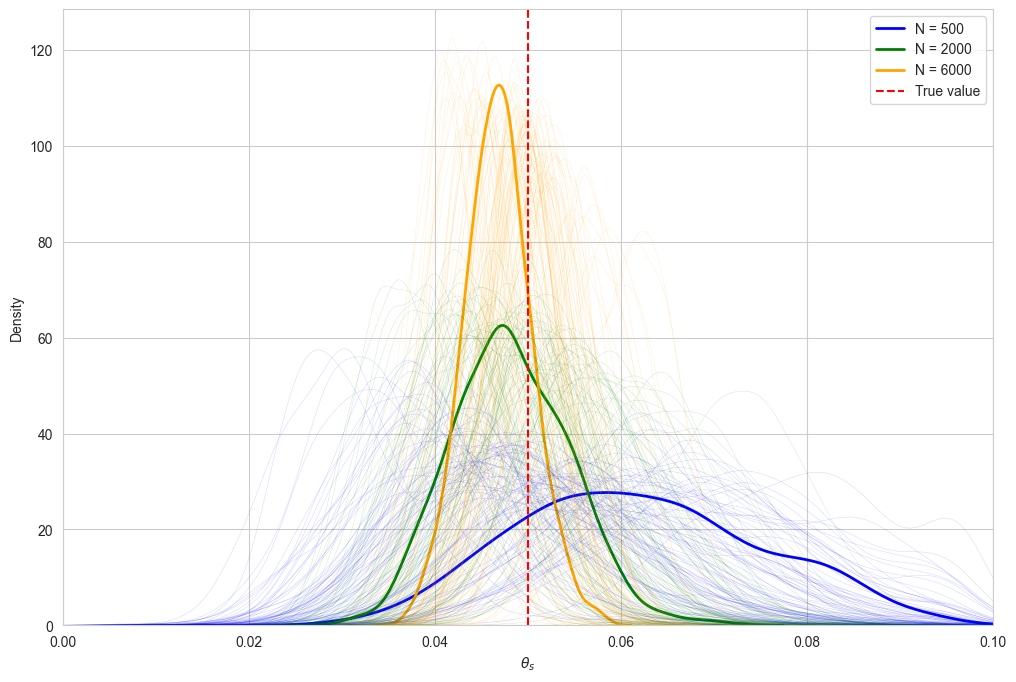

In [17]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

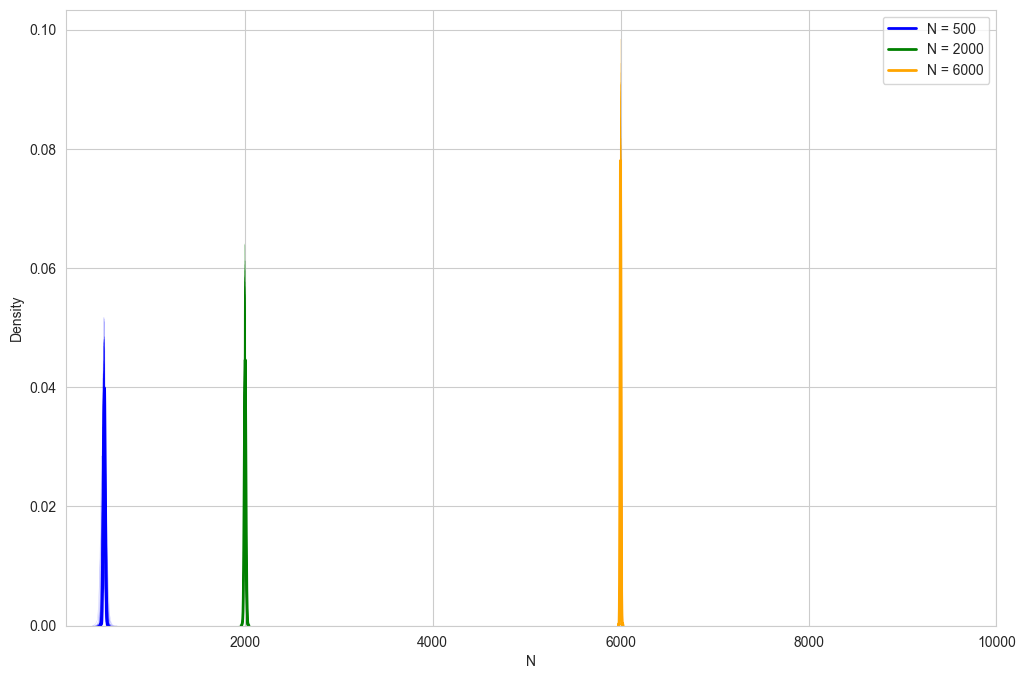

In [18]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 2], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 2], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 2], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 2], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 2], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 2], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

## Test estimated posterior

In [19]:
theta_test = np.loadtxt('../data/ClonalOrigin/rho_and_theta/theta_sbc.csv', delimiter=",")
x_test = np.loadtxt('../data/ClonalOrigin/rho_and_theta/x_sbc.csv', delimiter=",")

print(theta_test.shape, x_test.shape)
theta_test = torch.tensor(theta_test, device=torch_device)
theta_test = theta_test.to(torch.float32)
theta_numpy = theta_test.cpu().numpy()

x_test = torch.tensor(x_test, device=torch_device)
x_test = x_test.to(torch.float32)
x_test_numpy = x_test.cpu().numpy()

(1000, 3) (1000, 46)


In [20]:
nan_row = np.where(np.isnan(x_test_numpy))[0]
nan_row

array([865, 899])

In [21]:
theta_test = theta_test[~np.isnan(x_test_numpy).any(axis=1)]
x_test = x_test[~np.isnan(x_test_numpy).any(axis=1)]
theta_test.shape, x_test.shape

(torch.Size([998, 3]), torch.Size([998, 46]))

In [22]:
theta_numpy = theta_test.cpu().numpy()
x_test_numpy = x_test.cpu().numpy()

In [23]:
theta_test_post = np.full((theta_test.shape[0], num_posterior_samples, 3), np.nan)
for i in range(theta_test.shape[0]):
    theta_post = posterior1.sample((num_posterior_samples,), x=x_test[i, :], show_progress_bars=False)
    theta_test_post[i, :, :] = theta_post.cpu().numpy()

theta_test_post.shape

(998, 1000, 3)

In [24]:
post_mid_rho = np.median(theta_test_post[:, :, 0], axis=1)
post_mid_theta = np.median(theta_test_post[:, :, 1], axis=1)
post_mid_L = np.median(theta_test_post[:, :, 2], axis=1)
post_mid_rho.shape, post_mid_theta.shape, post_mid_L.shape

((998,), (998,), (998,))

In [25]:
rho_lower_bounds = np.percentile(theta_test_post[:, :, 0], 2.5, axis=1)
rho_upper_bounds = np.percentile(theta_test_post[:, :, 0], 97.5, axis=1)

theta_lower_bounds = np.percentile(theta_test_post[:, :, 1], 2.5, axis=1)
theta_upper_bounds = np.percentile(theta_test_post[:, :, 1], 97.5, axis=1)

l_lower_bounds = np.percentile(theta_test_post[:, :, 2], 2.5, axis=1)
l_upper_bounds = np.percentile(theta_test_post[:, :, 2], 97.5, axis=1)

rho_lower_bounds.shape, rho_upper_bounds.shape, theta_lower_bounds.shape, theta_upper_bounds.shape, l_lower_bounds.shape, l_upper_bounds.shape

((998,), (998,), (998,), (998,), (998,), (998,))

In [26]:
rho_lower_errors = post_mid_rho - rho_lower_bounds
rho_upper_errors = rho_upper_bounds - post_mid_rho
yerr_rho = [rho_lower_errors, rho_upper_errors]

theta_lower_errors = post_mid_theta - theta_lower_bounds
theta_upper_errors = theta_upper_bounds - post_mid_theta
yerr_theta = [theta_lower_errors, theta_upper_errors]

l_lower_errors = post_mid_L - l_lower_bounds
l_upper_errors = l_upper_bounds - post_mid_L
yerr_L = [l_lower_errors, l_upper_errors]

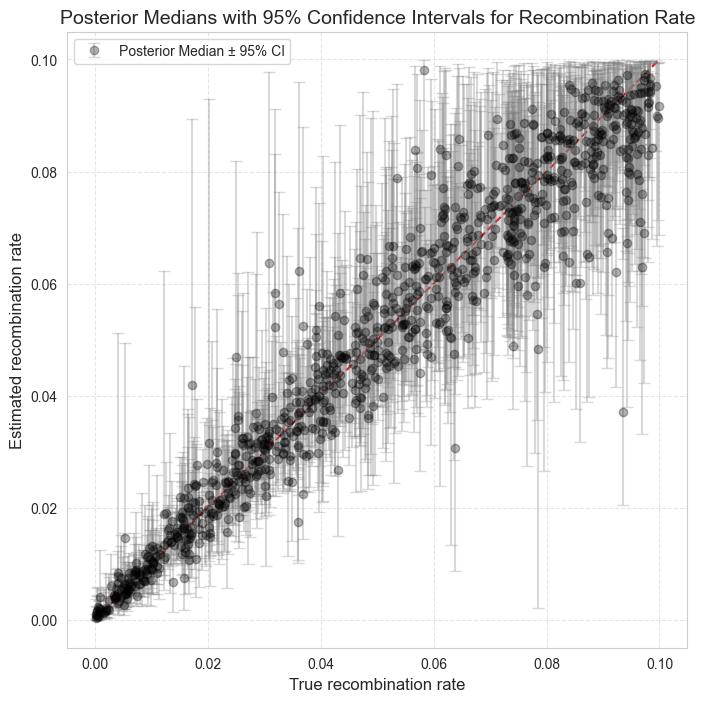

In [27]:
plt.figure(figsize=(8, 8))

exact_x = np.linspace(torch.min(theta_test[:, 0]), torch.max(theta_test[:, 0]), 400)
exact_y = exact_x
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')

plt.errorbar(theta_test[:, 0], post_mid_rho, yerr=yerr_rho, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for Recombination Rate", fontsize=14)
plt.xlabel("True recombination rate", fontsize=12)
plt.ylabel("Estimated recombination rate", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

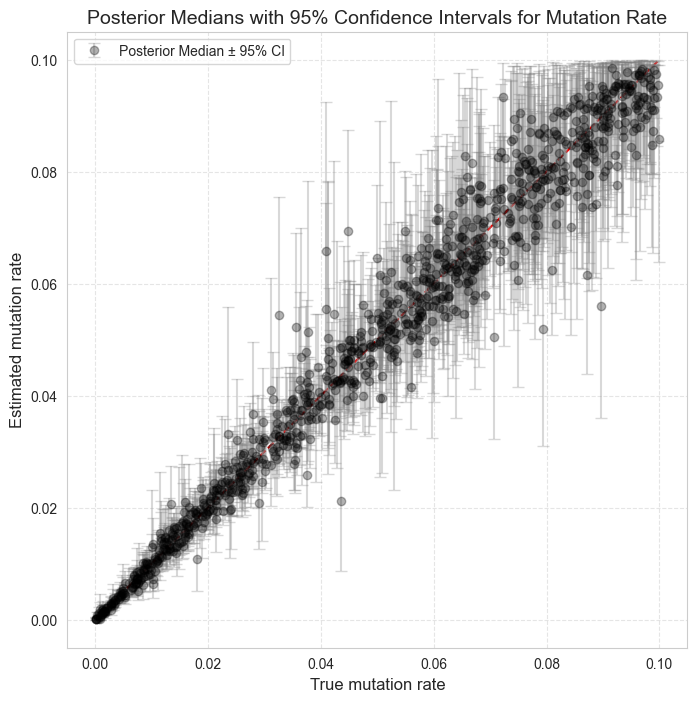

In [28]:
plt.figure(figsize=(8, 8))

exact_x = np.linspace(torch.min(theta_test[:, 1]), torch.max(theta_test[:, 1]), 400)
exact_y = exact_x
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')

plt.errorbar(theta_test[:, 1], post_mid_theta, yerr=yerr_theta, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for Mutation Rate", fontsize=14)
plt.xlabel("True mutation rate", fontsize=12)
plt.ylabel("Estimated mutation rate", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

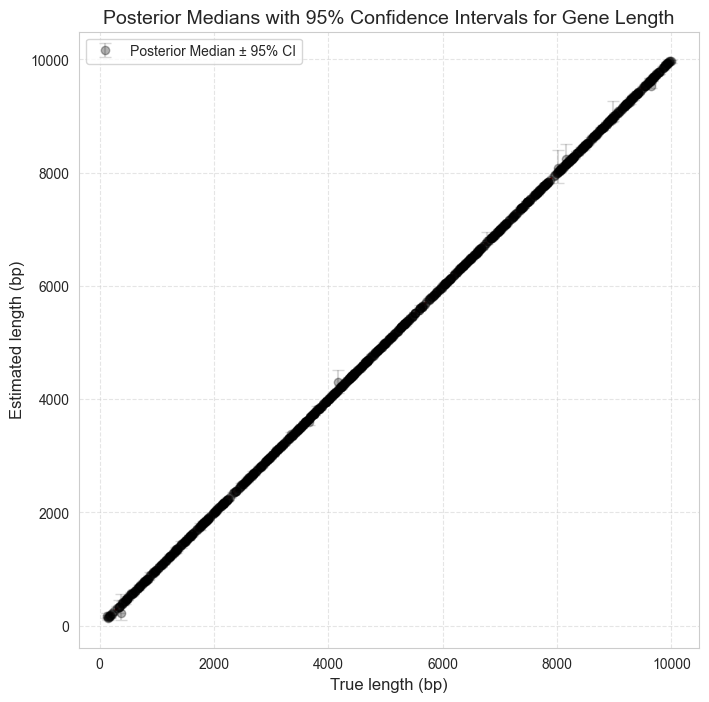

In [29]:
plt.figure(figsize=(8, 8))

exact_x = np.linspace(torch.min(theta_test[:, 2]), torch.max(theta_test[:, 2]), 400)
exact_y = exact_x
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')

plt.errorbar(theta_test[:, 2], post_mid_L, yerr=yerr_L, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

### SBC

In [30]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 6))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend()
    plt.show()

In [35]:
sbc_results = []
np.random.seed(100)
torch.manual_seed(100)
num_posterior_samples = 1000
parameter_labels = [r"for $\rho_s$", r"for $\theta_s$", r"for L"]
ranks, dap_samples = run_sbc(
    theta_test,
    x_test,
    posterior1,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False
)

stats_sbc = check_sbc(
    ranks, 
    theta_test, 
    dap_samples, 
    num_posterior_samples=num_posterior_samples
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats_sbc
})

Calculating ranks for 998 SBC samples: 100%|██████████| 998/998 [00:00<00:00, 16116.35it/s]


In [36]:
print("Kolmogorov-Smirnov Test Results (SBC):")
print("-" * 45)

num_dimensions = ranks.shape[1] 

for dim in range(num_dimensions):
    normalized_ranks = ranks[:, dim] / num_posterior_samples
    ks_stat, p_value = stats.kstest(normalized_ranks, 'uniform')
    
    print(f"Parameter:        {parameter_labels[dim]}")
    print(f"KS Statistic (D): {ks_stat:.4f}")
    print(f"p-value:          {p_value:.4e}")

    if p_value < 0.05:
        print("Status: MISCALIBRATED (reject null)")
    else:
        print("Status: CALIBRATED (fail to reject null)")
    print("-" * 45)

Kolmogorov-Smirnov Test Results (SBC):
---------------------------------------------
Parameter:        for $\rho_s$
KS Statistic (D): 0.0267
p-value:          4.6616e-01
Status: CALIBRATED (fail to reject null)
---------------------------------------------
Parameter:        for $\theta_s$
KS Statistic (D): 0.0238
p-value:          6.1423e-01
Status: CALIBRATED (fail to reject null)
---------------------------------------------
Parameter:        for L
KS Statistic (D): 0.1957
p-value:          6.0130e-34
Status: MISCALIBRATED (reject null)
---------------------------------------------


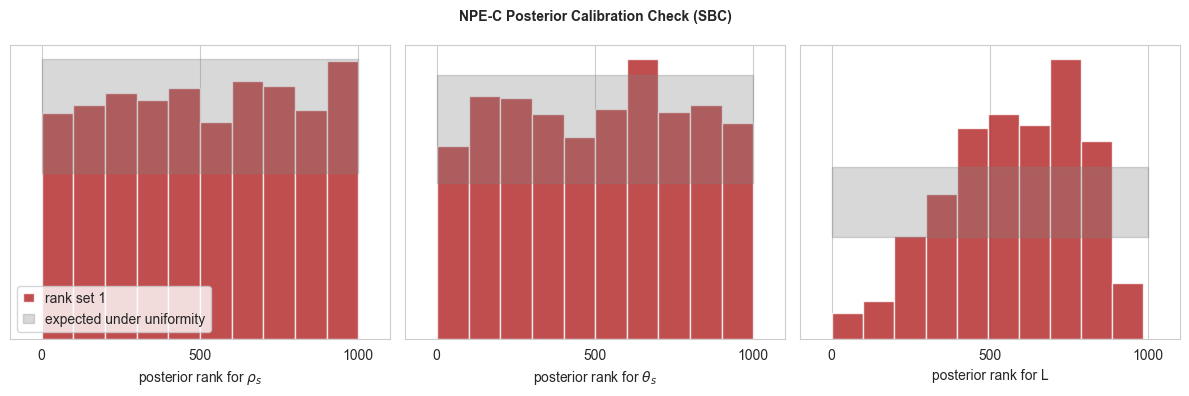

In [32]:
fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(12, 4),
    parameter_labels=[r"for $\rho_s$", r"for $\theta_s$", r"for L"]
)

fig.suptitle('NPE-C Posterior Calibration Check (SBC)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_9028\3449303370.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ranks_np = np.array(ranks)


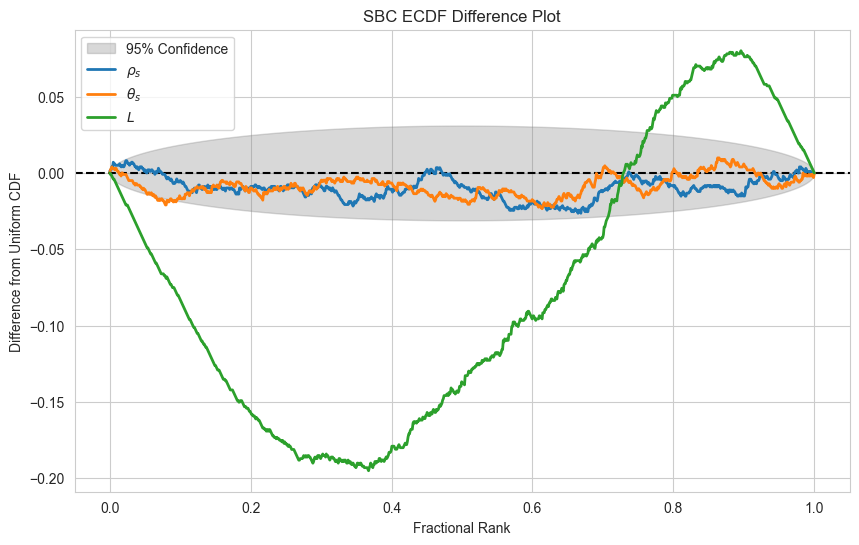

In [33]:
plot_sbc_ecdf_diff(ranks, num_posterior_samples=1000, param_names=[r"$\rho_s$", r"$\theta_s$", r"$L$"])

### Coverage at 95%

In [63]:
print("\nJoint 3D Coverage Metric:")
print("-" * 45)

num_test_samples = theta_numpy.shape[0]
joint_covered_count = 0

for i in range(num_test_samples):
    samples = theta_test_post[i]  # Shape: (1000, 3)
    truth = theta_numpy[i]        # Shape: (3,)

    mean_vec = np.mean(samples, axis=0)
    cov_matrix = np.cov(samples, rowvar=False)
    
    try:
        inv_cov = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        print(f"Warning: Singular covariance matrix at index {i}, skipping.")
        continue

    diff_samples = samples - mean_vec
    dist_samples = np.sum(np.dot(diff_samples, inv_cov) * diff_samples, axis=1)

    diff_truth = truth - mean_vec
    dist_truth = np.dot(np.dot(diff_truth, inv_cov), diff_truth)

    threshold_95 = np.percentile(dist_samples, 95)

    if dist_truth <= threshold_95:
        joint_covered_count += 1

joint_coverage_95 = joint_covered_count / num_test_samples

print(f"Target Joint Coverage: 95.0%")
print(f"Actual Joint Coverage: {joint_coverage_95 * 100:.1f}%")

if joint_coverage_95 < 0.90:
    print("  -> Warning: The joint posterior is systematically too narrow (overconfident).")
elif joint_coverage_95 > 0.99:
    print("  -> Warning: The joint posterior is systematically too wide (underconfident).")
print("-" * 45)


Joint 3D Coverage Metric:
---------------------------------------------
Target Joint Coverage: 95.0%
Actual Joint Coverage: 96.7%
---------------------------------------------


### Posterior mean error

In [54]:
post_mean_error = np.full((theta_test.shape[0]), np.nan)

In [55]:
for i in range(theta_test.shape[0]):
    post_mean = np.mean(theta_test_post[i, :, :], axis=0)
    error = post_mean - theta_numpy[i, :]
    post_mean_error[i] = np.linalg.norm(error)

In [56]:
post_mean_error

array([5.09441489e+00, 2.18504601e-01, 3.21720904e+00, 1.62983914e+01,
       3.64567182e+00, 1.94503901e+00, 1.06955756e+00, 6.18190050e+00,
       2.37959968e+00, 3.69301854e+00, 1.04542935e+00, 2.54339148e+00,
       2.08124832e+00, 1.20874961e+00, 1.54521751e+00, 2.07369353e+00,
       1.72057627e+00, 4.23674113e+00, 1.24440164e+00, 3.11301767e+00,
       1.91513923e+00, 3.11014925e+00, 7.00739547e-01, 1.36541055e+00,
       3.70052858e+00, 3.79413220e+00, 5.56171397e+00, 6.57598614e+00,
       6.10218154e+00, 3.20229017e+00, 1.71943073e+00, 2.52607692e+00,
       7.15902637e+00, 5.08582798e+00, 5.22724441e-01, 7.05586103e+00,
       1.16316362e+00, 6.73256064e-02, 3.22308636e+00, 1.36887944e+01,
       3.69180483e+00, 3.04315111e+00, 3.64525306e+00, 2.15646692e+00,
       1.36960162e+00, 9.15430184e+00, 3.84694671e+00, 6.67483388e+00,
       5.27132314e+00, 3.15261246e+00, 5.82898681e+00, 2.22796062e+00,
       6.39945270e+00, 7.23932782e-01, 6.42999565e+00, 7.03744572e+00,
      